Note to self from Fausto: use env pymc523

In [2]:
from scripts.data_functions import get_data, get_analysis_arrays, get_first_n_trials
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import xarray as xr
import arviz as az
import bambi as bmb
from scipy.stats import binomtest
from scripts.ceilingmodel import define_model

# Generic images

Display the shapes that the learning function can take:

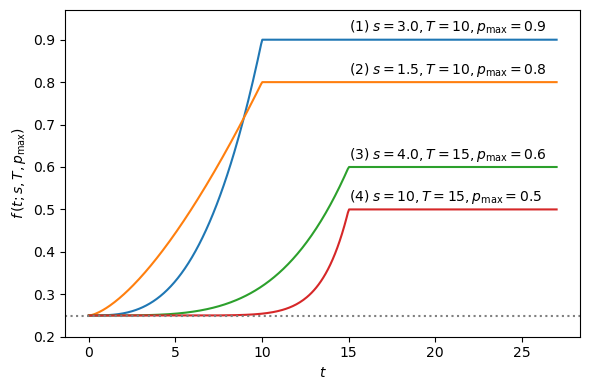

In [53]:
p0 = 0.25
params = [
    (3.0, 10, 0.9), 
    (1.5, 10, 0.8), 
    (4.0, 15, 0.6),
    (10, 15, 0.5), 
]

t = np.linspace(0, 27, 400)

plt.figure(figsize=(6, 4))
for i, (s, T, pmax) in enumerate(params):
    f = lambda t: np.where(t < T, p0 + (pmax - p0) * (t / T) ** s, pmax)
    plt.plot(t, f(t))
    plt.text(15, pmax+0.008, f"$({i+1})\\; s={s}, T={T}, p_{{\\max}}={pmax}$", ha='left', va='bottom')

plt.axhline(p0, ls=":", color="grey")
plt.xlabel("$t$")
plt.ylabel("$f\\,(t; s, T, p_{\\max})$")
plt.ylim(0.2, 0.97)
plt.tight_layout()
plt.savefig('./figures/ceiling_model_curves.png', dpi=300)


# Get data

In [3]:
datapath = '../data/langlearning_v2_anonymized.csv'
raw_data = pd.read_csv(datapath)

In [4]:
raw_data[raw_data['Field name'] == 'language']['Field value'].str.strip().str.lower()

14       english
52       english
90       english
128      english
166      english
          ...   
14492    english
14530    english
14568    english
14606    english
14644    english
Name: Field value, Length: 386, dtype: object

In [5]:
language_by_partic = raw_data.groupby('Results index').apply(
    lambda x: x[x['Field name'] == 'language']['Field value'].str.strip().str.lower()
)

/tmp/ipykernel_25622/1417206544.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  language_by_partic = raw_data.groupby('Results index').apply(


In [6]:
language_by_partic[language_by_partic != 'english']

Results index       
18             660                   urdu
88             3320               egnlish
173            6550               british
191            7234       british english
260            9856              englishs
271            10274    english (british)
338            12820               britsh
341            12934              british
Name: Field value, dtype: object

In [6]:
data = get_data()
analysis_arrays = get_analysis_arrays(data)

# analysis_arrays = get_first_n_trials(
#     analysis_arrays,
#     n_trials=100
# )

word_order_partic = analysis_arrays['word_order_partic'] 
interpretation_fs_partic = analysis_arrays['interpretation_fs_partic'] 
scenes_trials = analysis_arrays['scenes_trials'] 
true_scenes_trials = analysis_arrays['true_scenes_trials'] 
signals = analysis_arrays['signals'] 
history_choices_indices = analysis_arrays['history_choices_indices']
orders = analysis_arrays['orders']

/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:172: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(object_to_index_dict)
/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:177: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(word_to_index_dict)
/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:271: SettingWithCopyWarning: 
A value is trying to be set on a

In [7]:
right_answers = (history_choices_indices == 0).astype(int)

trial_index, participant_index = np.indices(
    history_choices_indices.shape
)

df = pd.DataFrame(
    data={
        'trial': trial_index.flatten(),
        'partic': participant_index.flatten(),
        # word orders
        'order': word_order_partic.values[
            participant_index.flatten()
        ],
        # signals,
        'correct': right_answers.flatten()
    }
)


In [9]:
df.partic.unique().shape

(325,)

# Calculate p-value of H that first trial accuracy =0.25

In [4]:
df_pvalue = df[df['trial']==0].groupby('order').agg(
    k=('correct', np.sum),
    N=('correct', 'count')
)

/tmp/ipykernel_25967/1770948749.py:1: FutureWarning: The provided callable <function sum at 0x7fa108372340> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_pvalue = df[df['trial']==0].groupby('order').agg(


In [5]:
df_pvalue = df_pvalue.reset_index()

In [6]:
df_pvalue

,order,k,N
0,osv,14,54
1,ovs,18,58
2,sov,8,51
3,svo,9,59
4,vos,12,49
5,vso,12,54


In [44]:
# Calculate two-tailed p-values for binomial test
# Using the binomial distribution with p=0.25 and N=60
def two_tailed_p(k, N, p):
    # Probability of the observed value
    observed_p = binom.pmf(k, N, p)
    # Get all pmf values
    pmfs = binom.pmf(np.arange(0, N + 1), N, p)
    # Two-tailed: sum of probabilities less than or equal to the observed
    p_val = pmfs[pmfs <= observed_p].sum()
    return p_val

In [51]:
# Recalculate two-tailed p-values using the updated Ns
df_pvalue['two_tailed_p'] = df_pvalue.apply(lambda row: binomtest(row['k'], row['N'], 0.25).pvalue, axis=1)
df_pvalue

,order,k,N,two_tailed_p
0,osv,14,54,0.875451
1,ovs,18,58,0.289935
2,sov,8,51,0.145931
3,svo,9,59,0.097578
4,vos,12,49,1.000000
5,vso,12,54,0.753867


# Model with learning cascade

$$
f(t;\,s,T)=
\begin{cases}
p_0 + \bigl(p_{\max}-p_0\bigr)\left(\dfrac{t}{T}\right)^{s}, & 0 \le t < T,\\[6pt]
p_{\max}, & t \ge T,
\end{cases}
\qquad s>1,\; T>0.
$$

In [10]:
cascade = define_model(df)

```{python}
with cascade:
    trace = pm.sample(
        draws       = 1000,
        tune        = 1000,
        # target_accept = 0.9,
        chains      = 4,
        cores       = 4,
        # init = "jitter+adapt_diag",
        # nuts_sampler='numpyro'
    )
    trace.to_netcdf('../results/cascademodel.cdf')
```

In [11]:
trace = az.from_netcdf('../results/cascademodel.cdf')

In [12]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Compute the p_row (which wasn't saved during sampling because it would take too much space). I am thinning it out because calculating it for all trace samples would take too much space.

In [16]:
# numeric participant and order codes
pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
P  = pid_codes.size                       # participants
K  = ord_codes.size                       # order levels

# For the order main effect we need one code *per participant*
order_per_pid = np.zeros(P, dtype=int)
order_per_pid[np.arange(P)] = ord_idx_t[np.searchsorted(pid_idx, np.arange(P))]

# trial indices per row 
t        = df.trial.values.astype("float32")
pid_row  = pid_idx.astype("int32")

s_row = trace.posterior.s_i.values[:,::10,pid_row]
T_row = trace.posterior.T_i.values[:,::10,pid_row]
C_row = trace.posterior.C_i.values[:,::10,pid_row]

ratio  = t / T_row
grow   = 0.25 + (C_row - 0.25) * ratio**s_row
p_row  = np.where(t < T_row, grow, C_row)


/tmp/ipykernel_10866/2709856264.py:20: RuntimeWarning: overflow encountered in power
  grow   = 0.25 + (C_row - 0.25) * ratio**s_row


# Prior predictives

In [8]:
cascade = define_model(df, True)

In [41]:
n_samples = 10

with cascade:
    prior_pred = pm.sample_prior_predictive(samples=n_samples)

Sampling: [log_T_i, log_s_i, logit_C_i, mu_log_T, mu_log_s, mu_logit_C, ord_C, ord_T, ord_s, sigma_log_T, sigma_log_s, sigma_logitC, y]


In [48]:
prior_pred

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [57]:
mu_logit_C = prior_pred.prior['mu_logit_C'].values.flatten()
sigma_logitC = prior_pred.prior['sigma_logitC'].values.flatten()

mu_log_s = mu_log_s = prior_pred.prior['mu_log_s'].values.flatten()
sigma_log_s = prior_pred.prior['sigma_log_s'].values.flatten()

mu_log_T = prior_pred.prior['mu_log_T'].values.flatten()
sigma_log_T = prior_pred.prior['sigma_log_T'].values.flatten()

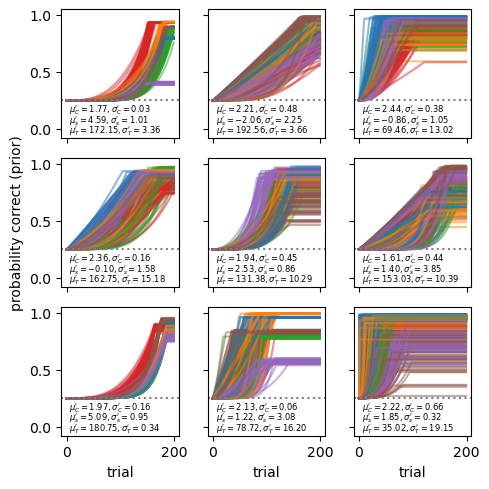

In [175]:
fig, axes = plt.subplots(
    3, 
    n_samples//3, 
    figsize=(5, 5), 
    sharex=True, 
    sharey=True
)

for i, ax in enumerate(axes.flatten()):

    ax.text(
        5, -0.04, 
        f"$\\mu_C' = {mu_logit_C[i]:.2f}, \\sigma_C' = {sigma_logitC[i]:.2f}$\n" +
        f"$\\mu_s' = {mu_log_s[i]:.2f}, \\sigma_s' = {sigma_log_s[i]:.2f}$\n" +
        f"$\\mu_T' = {mu_log_T[i]:.2f}, \\sigma_T' = {sigma_log_T[i]:.2f}$",
        fontsize=6,
        linespacing=0.7
    )

    # shape (# samples, N_rows,)
    p_sim = prior_pred.prior["p_row"].values.squeeze()[i]
    # t_row, pid_row are the same arrays built from df
    t_row   = df.trial.values
    # integer code per row
    pid_row = pid_idx
    P       = pid_codes.size

    # loop over participants
    for pid in range(P):
        
        rows = pid_row == pid
        color = f"C{ord_idx_t[np.argwhere(rows).flatten()[0]]}"
        ax.plot(
            t_row[rows], 
            p_sim[rows], 
            alpha=.5, 
            color=color
        )

    ax.axhline(0.25, color="grey", linestyle=":")

axes[1,0].set_ylabel("probability correct (prior)")
list(map(lambda a: a.set_xlabel('trial'), axes[-1]))
plt.ylim(-0.08, 1.05)
plt.tight_layout()
fig.savefig('figures/prior_pred.png', dpi=300)

# Parameter recovery

In [ ]:
from pickle import load
from glob import glob

pred_samples = {}
traces = {}

for fpath in glob('../param_recovery/pred_samples_*.json'):
    index = int(fpath.split('_')[-1].split('.')[0])
    with open(fpath, 'rb') as f:
        samples = load(f)
    pred_samples[index] = samples


In [48]:

for fpath in glob('../param_recovery/prior_pred_*.nc'):
    index = int(fpath.split('_')[-1].split('.')[0])
    trace = az.from_netcdf(fpath)
    traces[index] = trace


In [80]:
pred_vs_true = []
for i in range(len(pred_samples)):
    samples, predicted = pred_samples[i], traces[i]
    subdict = {}
    for k in samples.keys():
        true = np.array(predicted.prior.to_dict()['data_vars'][k]['data']).flatten()
        pred = samples[k].mean(0)
        subdict[k] = (true, pred)
    pred_vs_true.append(subdict)

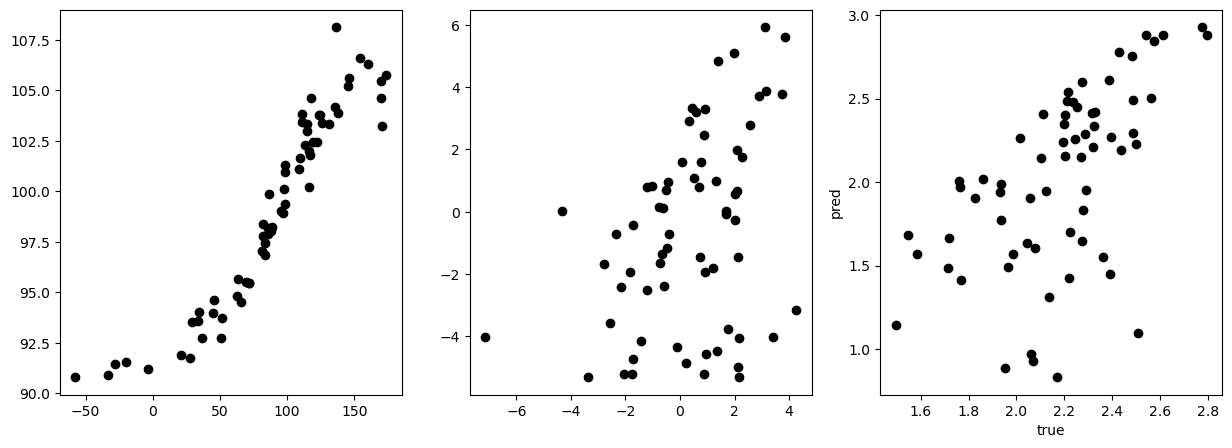

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, varname in zip(axes, ['mu_log_T', 'mu_log_s', 'mu_logit_C']):
    mu_log_comparison = [
        pred_vs_true[i][varname] for i in range(len(pred_vs_true))
    ]
    for x, y in mu_log_comparison:
        ax.scatter(x, y, c='black')

ax.set_xlabel('true')
ax.set_ylabel('pred')
plt.show()

# Analyse posterior

In [23]:
trace.posterior

<xarray.Dataset> Size: 253MB
Dimensions:          (chain: 16, draw: 1000, ord_s_dim_0: 6, ord_T_dim_0: 6,
                      ord_C_dim_0: 6, log_s_i_dim_0: 325, log_T_i_dim_0: 325,
                      logit_C_i_dim_0: 325, s_i_dim_0: 325, T_i_dim_0: 325,
                      C_i_dim_0: 325)
Coordinates:
  * chain            (chain) int64 128B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * ord_s_dim_0      (ord_s_dim_0) int64 48B 0 1 2 3 4 5
  * ord_T_dim_0      (ord_T_dim_0) int64 48B 0 1 2 3 4 5
  * ord_C_dim_0      (ord_C_dim_0) int64 48B 0 1 2 3 4 5
  * log_s_i_dim_0    (log_s_i_dim_0) int64 3kB 0 1 2 3 4 ... 320 321 322 323 324
  * log_T_i_dim_0    (log_T_i_dim_0) int64 3kB 0 1 2 3 4 ... 320 321 322 323 324
  * logit_C_i_dim_0  (logit_C_i_dim_0) int64 3kB 0 1 2 3 4 ... 321 322 323 324
  * s_i_dim_0        (s_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
  * T_i_dim_0        (T_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
  * C_i_dim_0        (C_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
Data variables: (12/15)
    mu_log_s         (chain, draw) float64 128kB ...
    mu_log_T         (chain, draw) float64 128kB ...
    mu_logit_C       (chain, draw) float64 128kB ...
    ord_s            (chain, draw, ord_s_dim_0) float64 768kB ...
    ord_T            (chain, draw, ord_T_dim_0) float64 768kB ...
    ord_C            (chain, draw, ord_C_dim_0) float64 768kB ...
    ...               ...
    sigma_log_s      (chain, draw) float64 128kB ...
    sigma_log_T      (chain, draw) float64 128kB ...
    sigma_logitC     (chain, draw) float64 128kB ...
    s_i              (chain, draw, s_i_dim_0) float64 42MB 1.001 1.0 ... 3.582
    T_i              (chain, draw, T_i_dim_0) float64 42MB 181.9 85.89 ... 118.4
    C_i              (chain, draw, C_i_dim_0) float64 42MB 0.5913 ... 0.9672
Attributes:
    created_at:                 2025-08-29T01:38:23.067705+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.23.0
    sampling_time:              12425.5658993721
    tuning_steps:               1000

array([[<Axes: title={'center': 'mu_log_s'}>,
        <Axes: title={'center': 'mu_log_s'}>],
       [<Axes: title={'center': 'sigma_log_s'}>,
        <Axes: title={'center': 'sigma_log_s'}>],
       [<Axes: title={'center': 'mu_log_T'}>,
        <Axes: title={'center': 'mu_log_T'}>],
       [<Axes: title={'center': 'sigma_log_T'}>,
        <Axes: title={'center': 'sigma_log_T'}>],
       [<Axes: title={'center': 'mu_logit_C'}>,
        <Axes: title={'center': 'mu_logit_C'}>],
       [<Axes: title={'center': 'sigma_logitC'}>,
        <Axes: title={'center': 'sigma_logitC'}>]], dtype=object)

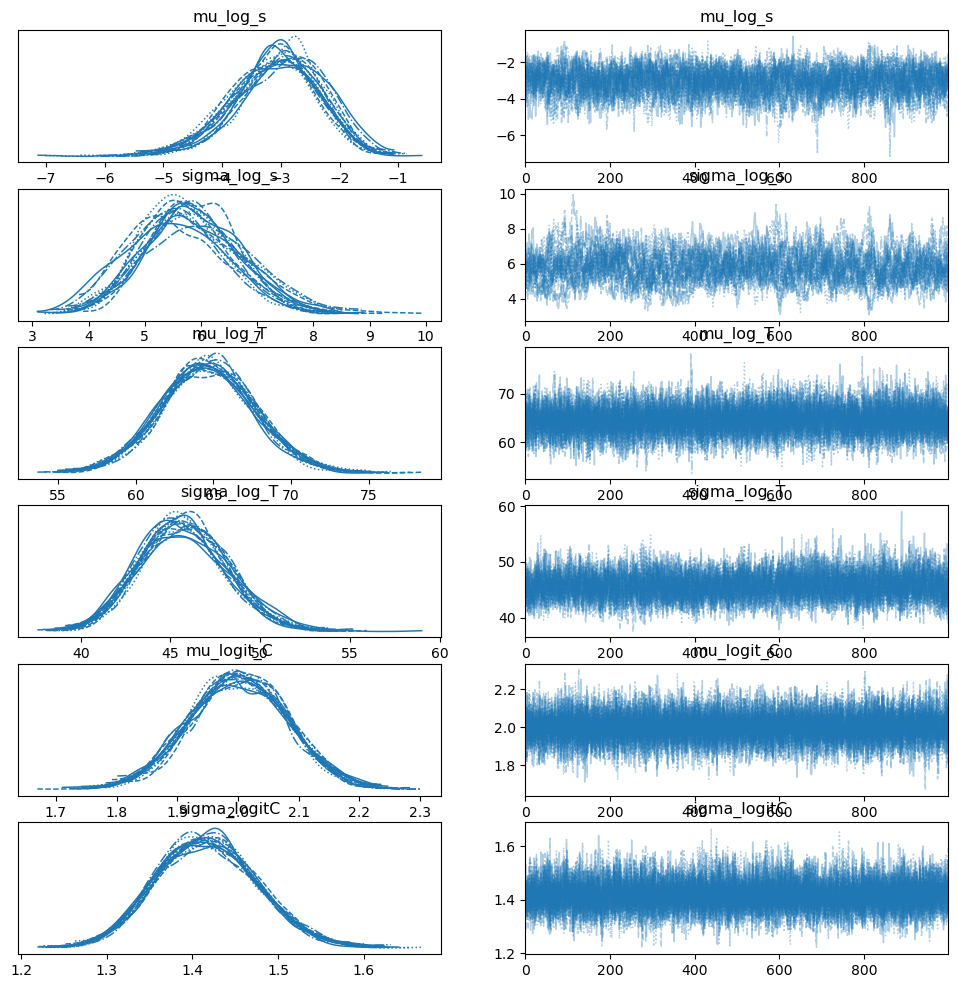

In [25]:
az.plot_trace(
    trace,
    ['mu_log_s', 'sigma_log_s', 'mu_log_T', 'sigma_log_T', 'mu_logit_C', 'sigma_logitC']
)

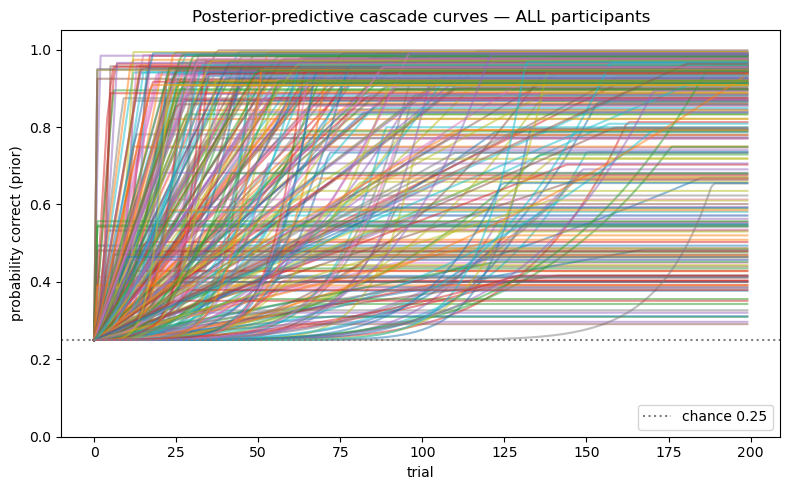

In [29]:
p_sim = p_row.squeeze()[0,50]     # shape (N_rows,)

# t_row, pid_row are the same arrays you built from df
t_row  = df.trial.values
pid_row= pid_idx                      # integer code per row
P      = pid_codes.size

plt.figure(figsize=(8, 5))

for pid in range(P):
    rows = pid_row == pid
    plt.plot(t_row[rows], p_sim[rows], alpha=.5)

plt.axhline(0.25, color="grey", linestyle=":", label="chance 0.25")
plt.xlabel("trial")
plt.ylabel("probability correct (prior)")
plt.title("Posterior-predictive cascade curves — ALL participants")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()

# Posterior ranking

In [227]:

# ------------------------------------------------------------
# 1.  Collapse the posterior to (samples , K)
# ------------------------------------------------------------
C_post = trace.posterior["ord_C"]                     # dims: (chain, draw, K)
labels  = list(ord_codes)                             # e.g. ['SVO','SOV',...]

C_arr = C_post.stack(sample=("chain", "draw")).values   # shape (K , S) or (S , K)
if C_arr.shape[0] == len(labels):                      # make sure rows = samples
    C_arr = C_arr.T                                    # -> (S , K)
S, K = C_arr.shape

# ------------------------------------------------------------
# 2.  Convert each sample to a ranking tuple
#     higher C ⇒ earlier in the tuple
# ------------------------------------------------------------
def ranking(row):
    return tuple(np.array(labels)[row.argsort()[::-1]])   # descending

rankings = [ranking(row) for row in C_arr]                # list of S tuples

# ------------------------------------------------------------
# 3.  Count and normalise
# ------------------------------------------------------------
rank_series = pd.Series(rankings, dtype="object")
rank_probs  = (rank_series.value_counts() / S).rename("prob")

# ------------------------------------------------------------
# 4.  Display the top‑N most probable rankings
# ------------------------------------------------------------
N = 10
print(f"\nTop {N} complete rankings of word orders by C (posterior):\n")
display(rank_probs.head(N).to_frame())

# …and, if you want the full distribution, keep `rank_probs`
# rank_probs.to_csv("ranking_posterior_C.csv")


Top 10 complete rankings of word orders by C (posterior):



,prob
"(svo, sov, vso, vos, osv, ovs)",0.157312
"(svo, sov, vso, osv, vos, ovs)",0.116375
"(svo, sov, vso, vos, ovs, osv)",0.098187
"(svo, vso, sov, vos, osv, ovs)",0.094375
"(svo, vso, sov, osv, vos, ovs)",0.065062
"(svo, sov, vso, osv, ovs, vos)",0.058313
"(svo, vso, sov, vos, ovs, osv)",0.053125
"(svo, sov, vso, ovs, vos, osv)",0.041313
"(svo, sov, vso, ovs, osv, vos)",0.032875
"(svo, vso, sov, osv, ovs, vos)",0.029063


In [231]:
# convert rows to string
print(rank_probs[:10].to_latex().replace("np.str_('", "").replace("')", ""))

\begin{tabular}{lr}
\toprule
 & prob \\
\midrule
(svo, sov, vso, vos, osv, ovs) & 0.157312 \\
(svo, sov, vso, osv, vos, ovs) & 0.116375 \\
(svo, sov, vso, vos, ovs, osv) & 0.098187 \\
(svo, vso, sov, vos, osv, ovs) & 0.094375 \\
(svo, vso, sov, osv, vos, ovs) & 0.065062 \\
(svo, sov, vso, osv, ovs, vos) & 0.058313 \\
(svo, vso, sov, vos, ovs, osv) & 0.053125 \\
(svo, sov, vso, ovs, vos, osv) & 0.041313 \\
(svo, sov, vso, ovs, osv, vos) & 0.032875 \\
(svo, vso, sov, osv, ovs, vos) & 0.029063 \\
\bottomrule
\end{tabular}



# Learning curves of individual participants

In [46]:
# numeric participant and order codes
pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
P  = pid_codes.size                       # participants
K  = ord_codes.size                       # order levels

# For the order main effect we need one code *per participant*
order_per_pid = np.zeros(P, dtype=int)
order_per_pid[np.arange(P)] = ord_idx_t[np.searchsorted(pid_idx, np.arange(P))]

# trial indices per row 
t        = df.trial.values.astype("float32")
pid_row  = pid_idx.astype("int32")

s_row = trace.posterior.s_i.values[:,::10,pid_row]
T_row = trace.posterior.T_i.values[:,::10,pid_row]
C_row = trace.posterior.C_i.values[:,::10,pid_row]

ratio  = t / T_row
grow   = 0.25 + (C_row - 0.25) * ratio**s_row
p_row  = np.where(t < T_row, grow, C_row)


AttributeError: 'Dataset' object has no attribute 's_i'

In [40]:
# ---- get p_row draws as (samples, N_rows) -------------------------
# stack chain & draw into one axis for convenience
# shape (N_rows, n_samples)
p_samples = p_row.reshape(-1, p_row.shape[-1])

# ---- basic info from the original dataframe ----------------------
if "partic" not in df.columns or "trial" not in df.columns:
    raise RuntimeError("The dataframe `df` must contain 'partic' and 'trial' columns.")

# re‑index participants 0…P‑1 if not done yet
pid_codes, pid_row = np.unique(df["partic"].values, return_inverse=True)
P = len(pid_codes)

# Convenience: bring trial & correct into arrays aligned with p_row
trial_row   = df["trial"].values
correct_row = df["correct"].values

# -------------------------------------------------------------------
# Create one PNG plot per participant in /mnt/data/
# -------------------------------------------------------------------
for pid in range(P):
    mask = pid_row == pid               # rows for this participant
    if mask.sum() == 0:
        continue

    trials = trial_row[mask]
    order  = np.argsort(trials)
    trials = trials[order]

    # slice & sort posterior samples correspondingly
    p_part = p_samples[:, mask][:, order]   # (samples, n_trials)
    mean   = p_part.mean(axis=0)
    hdi_lo = np.percentile(p_part, 2.5, axis=0)
    hdi_hi = np.percentile(p_part, 97.5, axis=0)

    # ---- plot -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(trials, hdi_lo, hdi_hi, color="tab:blue", alpha=0.25,
                    label="95% HDI")
    ax.plot(trials, mean, color="tab:blue", lw=2, label="posterior mean")

    # overlay raw data (jitter vertically for visibility)
    ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
               s=12, color="black", alpha=0.4, label="observed")

    ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
    ax.set(xlabel="trial", ylabel="accuracy",
           ylim=(-0.05, 1.05),
           title=f"Participant {pid_codes[pid]} – posterior accuracy curve")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()

    # ---- save -----------------------------------------------------
    fname = f"participant_{pid_codes[pid]}_accuracy.png"
    fig.savefig(fname, dpi=120)
    plt.close(fig)

print(f"✅ Generated {P} curve images to /mnt/data/")

✅ Generated 325 curve images to /mnt/data/


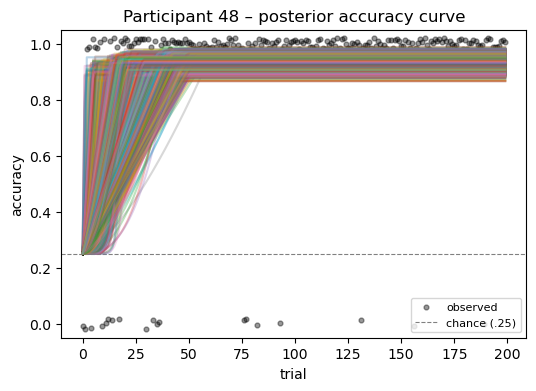

In [22]:
# rows for this participant
participant_index = 48
mask = pid_row == participant_index

fig, ax = plt.subplots(figsize=(6, 4))

trials = trial_row[mask]
order  = np.argsort(trials)
trials = trials[order]

# overlay raw data (jitter vertically for visibility)
ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
           s=12, color="black", alpha=0.4, label="observed")

ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
ax.set(xlabel="trial", ylabel="accuracy",
       ylim=(-0.05, 1.05),
       title=f"Participant {pid_codes[48]} – posterior accuracy curve")
ax.legend(loc="lower right", fontsize=8)

# slice & sort posterior samples correspondingly
p_part = p_samples[:, mask][:, order]   # (samples, n_trials)

for y in p_part:
    ax.plot(np.arange(len(y)), y, alpha=0.3)

fig.savefig('explicit_example.png', dpi=300)

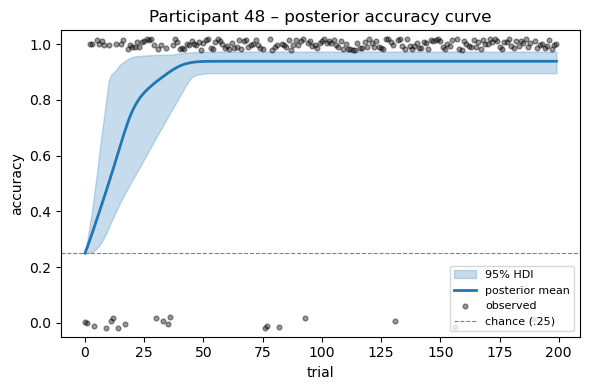

In [25]:
mean   = p_part.mean(axis=0)
hdi_lo = np.percentile(p_part, 2.5, axis=0)
hdi_hi = np.percentile(p_part, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(trials, hdi_lo, hdi_hi, color="tab:blue", alpha=0.25,
                label="95% HDI")
ax.plot(trials, mean, color="tab:blue", lw=2, label="posterior mean")

# overlay raw data (jitter vertically for visibility)
ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
           s=12, color="black", alpha=0.4, label="observed")

ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
ax.set(xlabel="trial", ylabel="accuracy",
       ylim=(-0.05, 1.05),
       title=f"Participant {pid_codes[participant_index]} – posterior accuracy curve")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()

# Pairwise comparisons of word orders

In [208]:
def pairwise_prob_greater(posterior_da: xr.DataArray,
                          labels: list[str]) -> pd.DataFrame:
    """
    posterior_da : xarray with dims (chain, draw, K)
    labels       : list of length K with the order names
    Returns a K×K DataFrame whose (i,j) entry is
        P( θ_i > θ_j | data )
    """
    # collapse chain & draw into one axis -> ndarray (A, B)
    a = posterior_da.stack(sample=("chain", "draw")).values          

    # ensure shape is (K, N_samples)
    K = len(labels)
    if a.shape[0] != K:          # orientation came out as (N_samples, K)
        a = a.T                  #      -->  transpose to (K, N_samples)

    # broadcast comparison across samples: (K,1,N) > (1,K,N)
    probs = (a[:, None, :] > a[None, :, :]).mean(axis=2)   # (K, K)

    return pd.DataFrame(probs, index=labels, columns=labels)



def style_extremes_lower_triangle(df: pd.DataFrame, cutoff=0.95, fmt="{:.3f}"):
    """
    Return a Styler that:
    - colors cells red if |p - 0.5| > cutoff - 0.5,
    - hides the upper triangle (including the diagonal) by making them blank.
    """
    def highlight(val):
        if pd.isna(val):
            return ""
        if (val > cutoff) or (val < 1 - cutoff):
            return "background-color:#ffcccc"
        return ""

    # Mask upper triangle including diagonal
    mask = np.triu(np.ones(df.shape), k=0).astype(bool)
    df_masked = df.mask(mask)

    # Custom formatter to suppress 'nan' display
    def safe_format(val):
        if pd.isna(val):
            return ""
        return fmt.format(val)

    return df_masked.style.applymap(highlight).format(safe_format)



In [210]:

# -----------------------------------------------------------------
# build the three tables
# -----------------------------------------------------------------
order_labels = list(ord_codes)   # e.g. ['SVO','SOV', ...]

prob_ord_s = pairwise_prob_greater(trace.posterior['ord_s'], order_labels)
prob_ord_T = pairwise_prob_greater(trace.posterior['ord_T'], order_labels)
prob_ord_C = pairwise_prob_greater(trace.posterior['ord_C'], order_labels)

In [216]:
# capitalize columns and rows
prob_ord_C.columns = [col.upper() for col in prob_ord_C.columns]
prob_ord_C.index = [index.upper() for index in prob_ord_C.index]

prob_ord_s.columns = [col.upper() for col in prob_ord_s.columns]
prob_ord_s.index = [index.upper() for index in prob_ord_s.index]

prob_ord_T.columns = [col.upper() for col in prob_ord_T.columns]
prob_ord_T.index = [index.upper() for index in prob_ord_T.index]

In [217]:

print("\nP( ord_s[row] > ord_s[col] )  – faster / steeper cascade\n")
display(style_extremes_lower_triangle(prob_ord_s))

print(style_extremes_lower_triangle(prob_ord_s).to_latex())



P( ord_s[row] > ord_s[col] )  – faster / steeper cascade



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,OSV,OVS,SOV,SVO,VOS,VSO
OSV,,,,,,
OVS,0.317,,,,,
SOV,0.481,0.660,,,,
SVO,0.421,0.606,0.442,,,
VOS,0.539,0.714,0.560,0.616,,
VSO,0.430,0.615,0.451,0.509,0.390,


\begin{tabular}{lrrrrrr}
 & OSV & OVS & SOV & SVO & VOS & VSO \\
OSV &  &  &  &  &  &  \\
OVS & 0.317 &  &  &  &  &  \\
SOV & 0.481 & 0.660 &  &  &  &  \\
SVO & 0.421 & 0.606 & 0.442 &  &  &  \\
VOS & 0.539 & 0.714 & 0.560 & 0.616 &  &  \\
VSO & 0.430 & 0.615 & 0.451 & 0.509 & 0.390 &  \\
\end{tabular}



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


In [218]:

print("\nP( ord_T[row] > ord_T[col] )  – later plateau "
      "(smaller means faster to ceiling)\n")
display(style_extremes_lower_triangle(prob_ord_T))

print(style_extremes_lower_triangle(prob_ord_T).to_latex())


P( ord_T[row] > ord_T[col] )  – later plateau (smaller means faster to ceiling)



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,OSV,OVS,SOV,SVO,VOS,VSO
OSV,,,,,,
OVS,0.462,,,,,
SOV,0.713,0.755,,,,
SVO,0.036,0.043,0.008,,,
VOS,0.830,0.860,0.669,0.998,,
VSO,0.616,0.654,0.390,0.984,0.244,


\begin{tabular}{lrrrrrr}
 & OSV & OVS & SOV & SVO & VOS & VSO \\
OSV &  &  &  &  &  &  \\
OVS & 0.462 &  &  &  &  &  \\
SOV & 0.713 & 0.755 &  &  &  &  \\
SVO & \background-color#ffcccc 0.036 & \background-color#ffcccc 0.043 & \background-color#ffcccc 0.008 &  &  &  \\
VOS & 0.830 & 0.860 & 0.669 & \background-color#ffcccc 0.998 &  &  \\
VSO & 0.616 & 0.654 & 0.390 & \background-color#ffcccc 0.984 & 0.244 &  \\
\end{tabular}



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


In [219]:
print("\nP( ord_C[row] > ord_C[col] )  – higher asymptotic accuracy\n")
display(style_extremes_lower_triangle(prob_ord_C))

print(style_extremes_lower_triangle(prob_ord_C).to_latex())


P( ord_C[row] > ord_C[col] )  – higher asymptotic accuracy



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,OSV,OVS,SOV,SVO,VOS,VSO
OSV,,,,,,
OVS,0.338,,,,,
SOV,0.989,0.997,,,,
SVO,1.000,1.000,0.908,,,
VOS,0.601,0.752,0.024,0.001,,
VSO,0.973,0.992,0.345,0.042,0.946,


\begin{tabular}{lrrrrrr}
 & OSV & OVS & SOV & SVO & VOS & VSO \\
OSV &  &  &  &  &  &  \\
OVS & 0.338 &  &  &  &  &  \\
SOV & \background-color#ffcccc 0.989 & \background-color#ffcccc 0.997 &  &  &  &  \\
SVO & \background-color#ffcccc 1.000 & \background-color#ffcccc 1.000 & 0.908 &  &  &  \\
VOS & 0.601 & 0.752 & \background-color#ffcccc 0.024 & \background-color#ffcccc 0.001 &  &  \\
VSO & \background-color#ffcccc 0.973 & \background-color#ffcccc 0.992 & 0.345 & \background-color#ffcccc 0.042 & 0.946 &  \\
\end{tabular}



/tmp/ipykernel_24306/2942636402.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


# Posterior predictive checks

In [17]:
with cascade:
    post_pred = pm.sample_posterior_predictive(
        trace.sel(draw=slice(None, None, 50)),  # InferenceData
        var_names=["y"],
        random_seed=42
    )

Sampling: [y]


Output()

In [18]:
# xarray → NumPy   shape: (chains , draws , rows)
y_pp_arr = post_pred.posterior_predictive["y"].values

chains, draws, N_rows = y_pp_arr.shape
# total samples
S = chains * draws

# reshape to (rows , samples)
y_pp_samples = y_pp_arr.reshape(chains * draws, N_rows).T

# Quick references from the original DF
orders_arr  = df["order"].values
trials_arr  = df["trial"].values
correct_arr = df["correct"].values

# e.g. ['SVO','SOV',...]
order_levels = list(ord_codes)

# Compute empirical & posterior-predictive means
records = []
for ord_label in order_levels:
    rows_ord = orders_arr == ord_label
    for t in np.unique(trials_arr[rows_ord]):
        rows = rows_ord & (trials_arr == t)
        idx  = np.where(rows)[0]

        emp_mean = correct_arr[idx].mean()

        # posterior predictive: mean over those rows, for every sample
        sample_means = y_pp_samples[idx].mean(axis=0)   # shape (S,)
        post_mean = sample_means.mean()
        hdi_low, hdi_high = az.hdi(sample_means, hdi_prob=0.95)

        records.append(dict(order=ord_label, trial=t,
                            emp=emp_mean,
                            post=post_mean,
                            lo=hdi_low, hi=hdi_high))

df_plot = pd.DataFrame(records).sort_values(["order", "trial"])

In [21]:
df_plot.to_csv('empirical_vs_posteriorpred.csv', index=False)

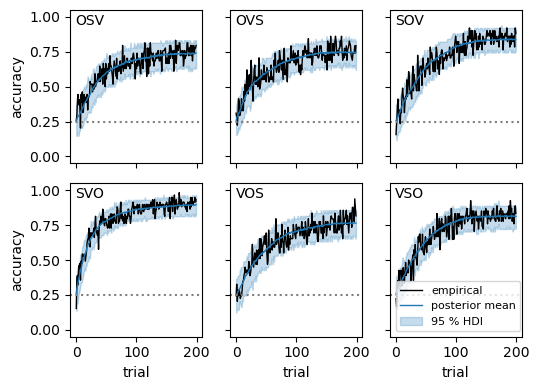

In [19]:

n_col = 3
n_row = int(np.ceil(len(order_levels) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(5.5, 2. * n_row), sharey=True, sharex=True)

for ax, ord_label in zip(axes.flat, order_levels):
    sub = df_plot.query("order == @ord_label")
    ax.plot(sub.trial, sub.emp,  c="black", lw=1, label="empirical")
    ax.plot(sub.trial, sub.post, c="tab:blue", lw=1, label="posterior mean")
    ax.fill_between(sub.trial, sub.lo, sub.hi, color="tab:blue", alpha=0.25,
                    label="95 % HDI")
    ax.axhline(0.25, ls=":", c="grey")
    # capitalize the whole ord_label (not just the first letter)
    ax.text(0.15, 0.93, f"{ord_label.upper()}", transform=ax.transAxes, ha="center", va="center")
    ax.set_ylim(-0.05, 1.05)
    
for ax in axes[-1]:
    ax.set_xlabel("trial")

for ax in axes[:,0]:
    ax.set_ylabel("accuracy")

axes[1,-1].legend(fontsize=8)

# remove empty panels if K is odd
for ax in axes.flat[len(order_levels):]:
    fig.delaxes(ax)

plt.tight_layout()
# plt.savefig('./figures/empirical_vs_posteriorpred.png', dpi=300)

## Model criticism

In [ ]:
overall_accuracy = (
    y_pp_arr.reshape(chains * draws, N_rows).mean(axis=1) > df.correct.mean()
).mean()
overall_accuracy

np.float64(0.065625)

In [207]:
accuracy_by_word_order = []
for ord_label in order_levels:
    rows_ord = orders_arr == ord_label
    accuracy = y_pp_arr.reshape(chains * draws, N_rows)[:, rows_ord].mean(1)
    accuracy_by_word_order.append(accuracy)
accuracy_by_word_order = np.array(accuracy_by_word_order)

for i, ord_label in enumerate(order_levels):
    p_value = (accuracy_by_word_order[i] > df.groupby('order').correct.mean().values[i]).mean()
    print(f"{ord_label}: {p_value:.3f}")


osv: 0.222
ovs: 0.234
sov: 0.256
svo: 0.156
vos: 0.381
vso: 0.469


In [ ]:
accuracy_by_trial = []
for trial_idx in df.trial.unique():
    rows = df.trial == trial_idx
    accuracy = y_pp_arr.reshape(chains * draws, N_rows)[:, rows].mean(1)
    accuracy_by_trial.append(accuracy)
accuracy_by_trial = np.array(accuracy_by_trial)


(200, 320)

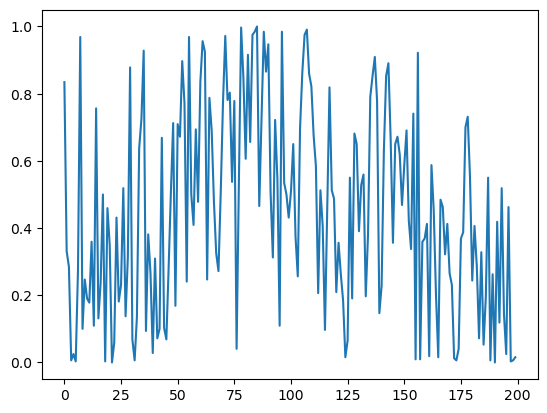

In [33]:
plt.plot(
    (accuracy_by_trial.T > df.groupby('trial').correct.mean().values).mean(0)
)
plt.show()


In [ ]:
(y_pp_arr.reshape(chains * draws, N_rows).mean(axis=1) > df.correct.mean())

array([False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True, False, False, False, False,
        True, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False,

# Bambi model

In [6]:
def logit(p):
   p = np.clip(p, 1e-15, 1 - 1e-15) # Clip to avoid log(0) and log(negative) errors
   return np.log(p / (1 - p))

In [8]:
bmb_df = df.copy(deep=True)

bmb_df.loc[:, 'scaled_trial'] = bmb_df.trial / bmb_df.trial.max()

bmb_df["offset_intercept"] = logit(0.25)

model = bmb.Model(
     "correct ~ 0 + np.sqrt(trial):order + offset(offset_intercept) + (1|partic)",
    family='bernoulli',
    link='logit',
    categorical=['order', 'partic'],
    data=bmb_df
)

In [9]:
model.build()

In [10]:
model

       Formula: correct ~ 0 + np.sqrt(trial):order + offset(offset_intercept) + (1|partic)
        Family: bernoulli
          Link: p = logit
  Observations: 65000
        Priors: 
    target = p
        Common-level effects
            np.sqrt(trial):order ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [0.2975 0.2975 0.2975 0.2975
                0.2975 0.2975])
        
        
        Group-level effects
            1|partic ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.749))
        
        Offset effects
            offset(offset_intercept) ~ 1

Run this to generate the file:

```{python}
trace_bmb = model.fit(idata_kwargs={"log_likelihood": True})
trace_bmb.to_netcdf('../results/logisticregression.cdf')
```

In [11]:
trace_bmb = az.from_netcdf('../results/logisticregression.cdf')

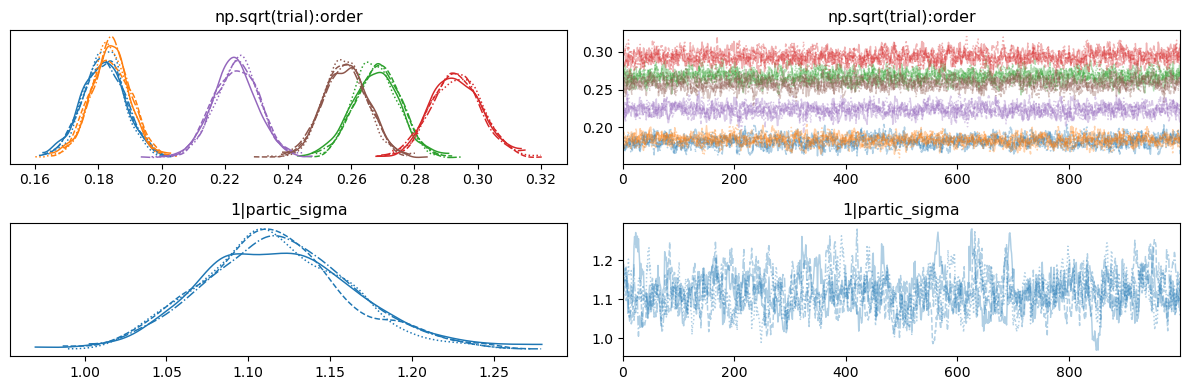

In [12]:
az.plot_trace(trace_bmb, var_names="~1|partic")
plt.tight_layout()

In [14]:
az.summary(trace_bmb, var_names=["np.sqrt(trial):order"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
np.sqrt(trial):order[osv],0.182,0.007,0.169,0.195,0.0,0.0,650.0,1347.0,1.0
np.sqrt(trial):order[ovs],0.184,0.006,0.172,0.195,0.0,0.0,893.0,1429.0,1.0
np.sqrt(trial):order[sov],0.268,0.007,0.254,0.281,0.0,0.0,863.0,1499.0,1.0
np.sqrt(trial):order[svo],0.293,0.008,0.279,0.309,0.0,0.0,907.0,1729.0,1.0
np.sqrt(trial):order[vos],0.224,0.007,0.209,0.236,0.0,0.0,938.0,1659.0,1.0
np.sqrt(trial):order[vso],0.258,0.007,0.245,0.271,0.0,0.0,816.0,1570.0,1.0


In [32]:
model

       Formula: correct ~ 0 + np.sqrt(trial):order_id + offset(offset_intercept) + (1|partic)
        Family: bernoulli
          Link: p = logit
  Observations: 65000
        Priors: 
    target = p
        Common-level effects
            np.sqrt(trial):order_id ~ Normal(mu: 0.0, sigma: 0.0537)
        
        Group-level effects
            1|partic ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.7826))
        
        Offset effects
            offset(offset_intercept) ~ 1
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for unspecified variable: offset_intercept, partic


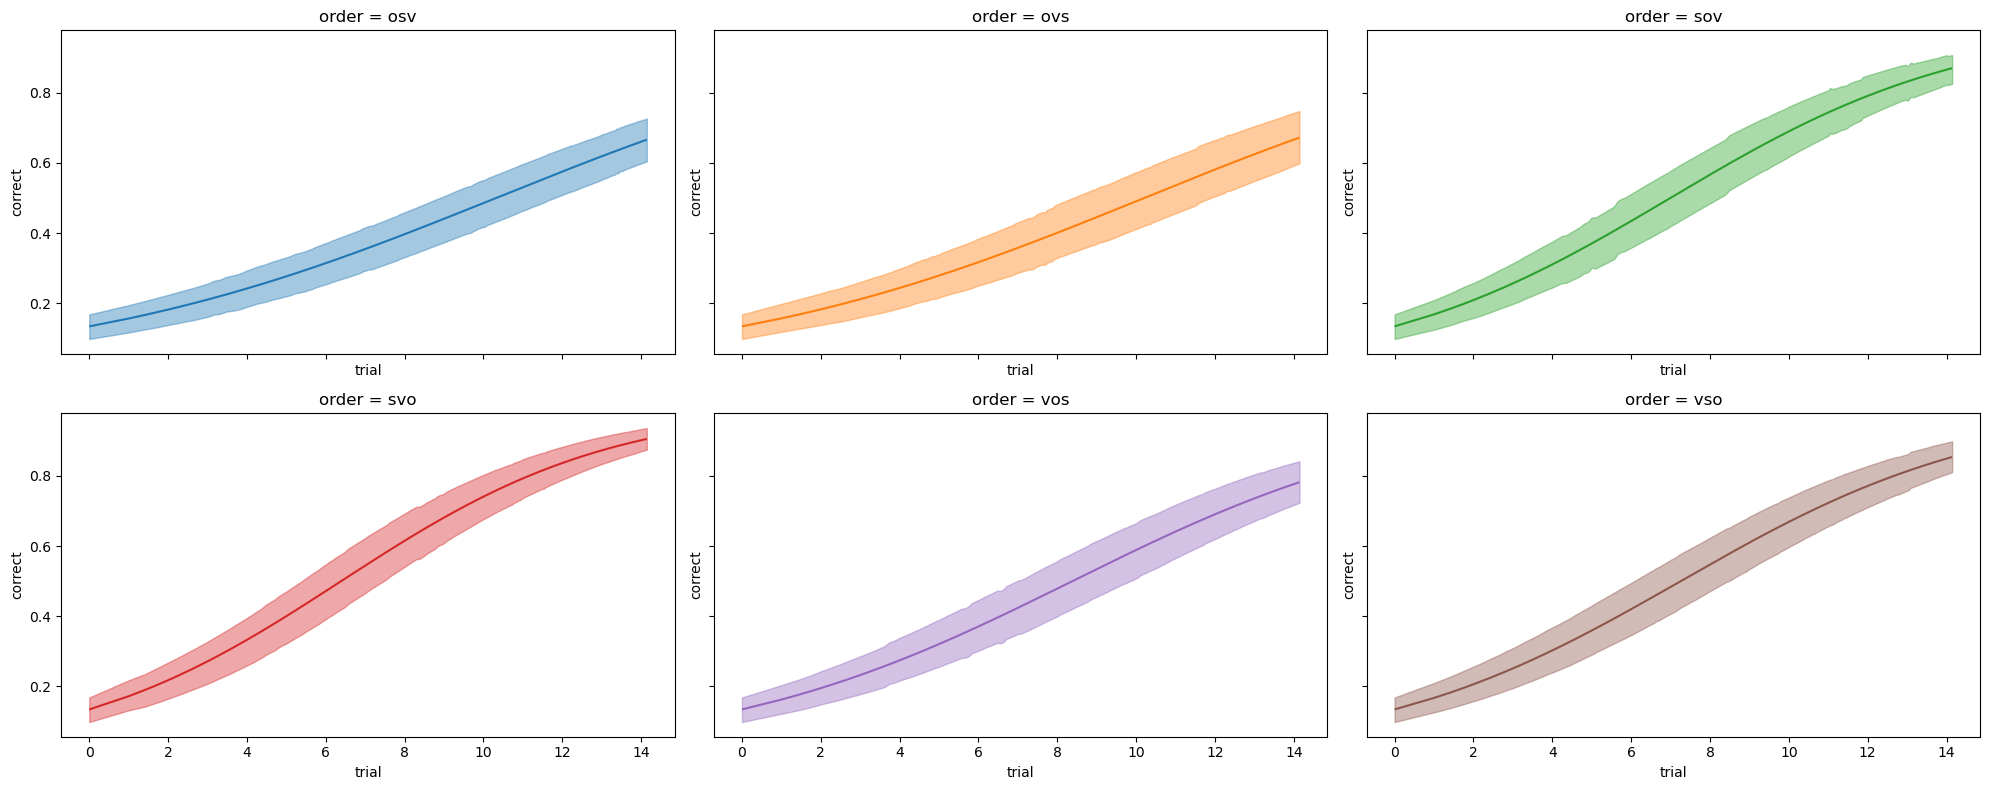

In [40]:
trial_vals   = np.arange(0, 201)                           # 0 … 200
order_levels = model.data["order"].cat.categories

fig, ax = bmb.interpret.plot_predictions(
    model,
    trace_bmb,                         # your InferenceData trace
    conditional={
        "trial": trial_vals,                                # x‑axis
        "order": order_levels,                           # colour
        # "offset_intercept": [logit(0.25)],          # logit(0.25)
    },
    transforms={"trial": np.sqrt},     # feed √trial to the model
    subplot_kwargs={"main": "trial", "group": "order", "panel": "order"},
    use_hdi=True,
    legend=False,
    fig_kwargs={"figsize": (20, 8), "sharey": True, "sharex": True},
)

# # 1 – place ticks at the √‑positions …
# raw_ticks = np.arange(0, 201, 50)          # 0, 50, 100, 150, 200
# ax[0,0].set_xticks(np.sqrt(raw_ticks))
# # 2 – … but label them with the raw numbers
# ax[0,0].set_xticklabels(raw_ticks)
# ax[0,0].set_xlim(0, np.sqrt(200))

# ax.set_xlabel("Trial number (0–200)")
# ax.set_ylabel("P(correct)")
# ax.set_title("Predicted accuracy over trials by word order");
plt.tight_layout()


In [25]:
print(ord_codes)

['osv' 'ovs' 'sov' 'svo' 'vos' 'vso']


In [17]:
idata_thin

<xarray.Dataset> Size: 272kB
Dimensions:                   (np.sqrt(trial):order_dim: 6, sample: 100,
                               partic__factor_dim: 325)
Coordinates:
  * np.sqrt(trial):order_dim  (np.sqrt(trial):order_dim) <U3 72B 'osv' ... 'vso'
  * partic__factor_dim        (partic__factor_dim) <U3 4kB '0' '1' ... '324'
  * sample                    (sample) object 800B MultiIndex
  * chain                     (sample) int64 800B 3 3 3 0 1 2 1 ... 3 1 1 1 0 3
  * draw                      (sample) int64 800B 288 840 237 50 ... 672 394 635
Data variables:
    np.sqrt(trial):order      (np.sqrt(trial):order_dim, sample) float64 5kB ...
    1|partic_sigma            (sample) float64 800B 1.156 1.171 ... 1.122 1.149
    1|partic                  (partic__factor_dim, sample) float64 260kB -0.8...
Attributes:
    created_at:                  2025-06-12T18:23:35.582329+00:00
    arviz_version:               0.21.0
    inference_library:           pymc
    inference_library_version:   5.23.0
    sampling_time:               173.6335690021515
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0

In [19]:
idata_thin

<xarray.Dataset> Size: 272kB
Dimensions:                   (np.sqrt(trial):order_dim: 6, sample: 100,
                               partic__factor_dim: 325)
Coordinates:
  * np.sqrt(trial):order_dim  (np.sqrt(trial):order_dim) <U3 72B 'osv' ... 'vso'
  * partic__factor_dim        (partic__factor_dim) <U3 4kB '0' '1' ... '324'
  * sample                    (sample) object 800B MultiIndex
  * chain                     (sample) int64 800B 2 1 0 3 1 2 3 ... 0 3 2 3 1 1
  * draw                      (sample) int64 800B 578 504 447 472 ... 78 281 202
Data variables:
    np.sqrt(trial):order      (np.sqrt(trial):order_dim, sample) float64 5kB ...
    1|partic_sigma            (sample) float64 800B 1.061 1.032 ... 1.081 1.103
    1|partic                  (partic__factor_dim, sample) float64 260kB -0.9...
Attributes:
    created_at:                  2025-06-12T18:23:35.582329+00:00
    arviz_version:               0.21.0
    inference_library:           pymc
    inference_library_version:   5.23.0
    sampling_time:               173.6335690021515
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0

In [57]:
thin_every = 5                      # keep every 20‑th draw  → 2000/20 ≈ 100 draws
idata_thin = trace_bmb.sel(draw=slice(None, None, thin_every))   # preserves 'chain'!

In [59]:
pred_draws = model.predict(
    idata=idata_thin,
    data=grid,
    include_group_specific=False,     # <- no (1|partic) random effects
    kind="response_params",         # replaces kind="mean"
    inplace=False,
)   # shape: (n_draws, n_grid_rows)

In [60]:
# 1.  The DataArray with shape (chain, draw, obs)
p_da = pred_draws.posterior["p"]          # <ArviZ DataArray>

# 2.  Stack chain+draw into a single axis called "sample"
p_stack = p_da.stack(sample=("chain", "draw"))

# 3.  Summary stats across all posterior samples
grid["mean"]  = p_stack.mean("sample").values
grid["lower"] = p_stack.quantile(0.025, dim="sample").values
grid["upper"] = p_stack.quantile(0.975, dim="sample").values

In [61]:
summ = az.summary(pred_draws, var_names=["p"], hdi_prob=0.95)
grid["mean"]  = summ["mean"].values
grid["lower"] = summ["hdi_2.5%"].values
grid["upper"] = summ["hdi_97.5%"].values

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


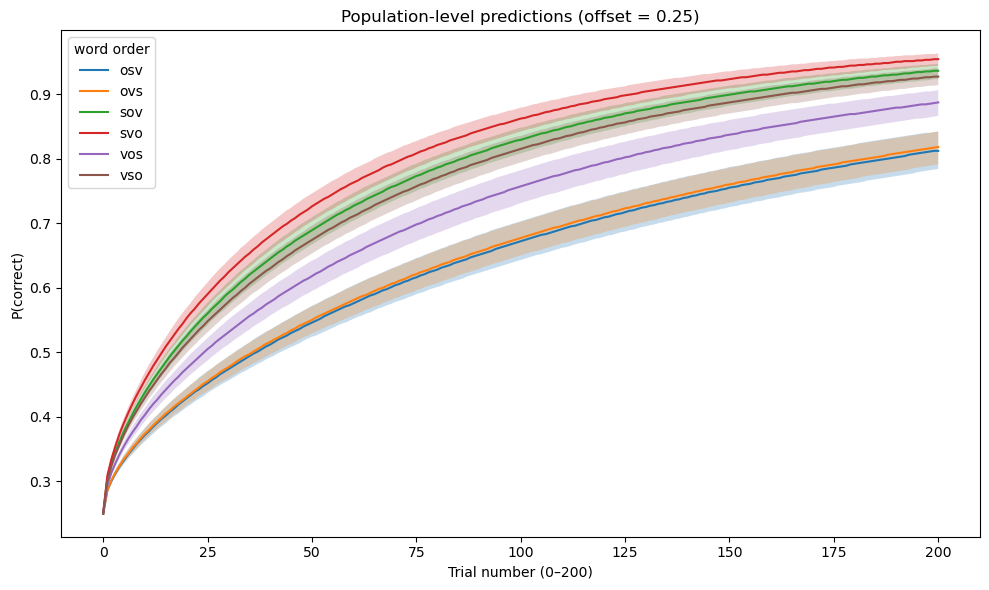

In [62]:
plt.figure(figsize=(10, 6))
for order in order_levels:
    sub = grid[grid["order"] == order]
    plt.plot(sub["trial"], sub["mean"], label=order)
    plt.fill_between(sub["trial"], sub["lower"], sub["upper"], alpha=0.25)

plt.xlabel("Trial number (0–200)")
plt.ylabel("P(correct)")
plt.title("Population‑level predictions (offset = 0.25)")
plt.legend(title="word order")
plt.tight_layout()
plt.show()

# Truncated logistic curve

In [5]:
def define_logistic_model(df, include_p_row=False, fix_T=False, normalize_t=False, clip_p=False):
    # NOTE: Here T is the ceiling (what is called C in the other model)
    # I got confused when I was writing this. Sue me!

    # numeric participant and order codes
    pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
    ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
    P  = pid_codes.size                       # participants
    K  = ord_codes.size                       # order levels

    # For the order main effect we need one code *per participant*
    order_per_pid = np.zeros(P, dtype=int)
    order_per_pid[np.arange(P)] = ord_idx_t[np.searchsorted(pid_idx, np.arange(P))]

    # trial indices per row 
    t        = df.trial.values.astype("float32")
    pid_row  = pid_idx.astype("int32")
    y_obs    = df.correct.values.astype("int8")

    if normalize_t:
        t = t / t.max()

    with pm.Model() as logistic:

        if not fix_T:
            # ceiling T_i (on probability scale); prior around ~0.9 like before
            mu_logit_T    = pm.Normal("mu_logit_T", pm.math.logit(0.9), 0.3)
            sigma_logitT  = pm.HalfNormal("sigma_logitT", 0.3)
            ord_T         = pm.Normal("ord_T", 0., 1.0, shape=K)
            ord_T         = ord_T - pm.math.mean(ord_T)
            logit_T_i = pm.Normal(
                "logit_T_i",
                mu_logit_T + ord_T[order_per_pid],
                sigma_logitT,
                shape=P
            )
            T_i    = pm.Deterministic("T_i", pm.math.sigmoid(logit_T_i))    # in (0,1)
            T_row  = T_i[pid_row]

        # ---------------- hyper-priors (weakly informative) ----------------
        # logistic intercept fixed at logit(0.25); only slope is learned
        mu_log_beta   = pm.Normal("mu_log_beta", -2., 1.0)       # group mean (log-slope)
        sigma_log_beta= pm.HalfNormal("sigma_log_beta", 1)    # between-participant SD

        # order effects with sum-to-zero constraint
        ord_beta = pm.Normal("ord_beta", 0., 0.5, shape=K)
        ord_beta = ord_beta - pm.math.mean(ord_beta)            

        # ---------------- participant-level parameters --------------------
        log_beta_i = pm.Normal(
            "log_beta_i",
            mu_log_beta + ord_beta[order_per_pid],
            sigma_log_beta,
            shape=P
        )
        
        # transform to natural scales
        beta_i = pm.Deterministic("beta_i", pm.math.log1pexp(log_beta_i))  # > 0
        
        # ---------------- row-wise probabilities --------------------------
        # fixed intercept so that p(t=0) = 0.25
        logit_intercept = pm.math.logit(pm.math.constant(0.25))
        beta_row = beta_i[pid_row]

        # raw logistic (would asymptote to 1 without truncation)
        logit_p  = logit_intercept + beta_row * t
        p_row    = pm.math.sigmoid(logit_p)

        # truncate at the participant ceiling T
        if not fix_T:
            p_row    = pm.math.minimum(p_row, T_row)

        if include_p_row:
            pm.Deterministic("p_row", p_row)

        if clip_p:
            eps = 10e-6
            p_row = pm.math.clip(p_row, eps, 1 - eps)

        pm.Bernoulli("y", p_row, observed=y_obs)
    
    return logistic

## Model no ceiling

In [8]:
logistic_no_ceiling = define_logistic_model(df, fix_T=True, clip_p=True)

In [14]:
with logistic_no_ceiling:
    trace_no_ceiling = pm.sample(
        draws       = 1000,
        tune        = 1000,
        target_accept = 0.99,
        chains      = 4,
        # cores       = 4,
        # init = "jitter+adapt_diag",
        # nuts_sampler='numpyro'
    )
    trace_no_ceiling.to_netcdf('../results/logisticmodel_no_ceiling.cdf')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_log_beta, sigma_log_beta, ord_beta, log_beta_i]


Output()

ValueError: Not enough samples to build a trace.

## Model with ceiling

In [42]:
logistic = define_logistic_model(df)

In [43]:
with logistic:
    trace = pm.sample(
        draws       = 1000,
        tune        = 1000,
        # target_accept = 0.9,
        chains      = 4,
        cores       = 4,
        # init = "jitter+adapt_diag",
        # nuts_sampler='numpyro'
    )
    trace.to_netcdf('../results/logisticmodel.cdf')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_log_beta, sigma_log_beta, mu_logit_T, sigma_logitT, ord_beta, ord_T, log_beta_i, logit_T_i]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1914 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


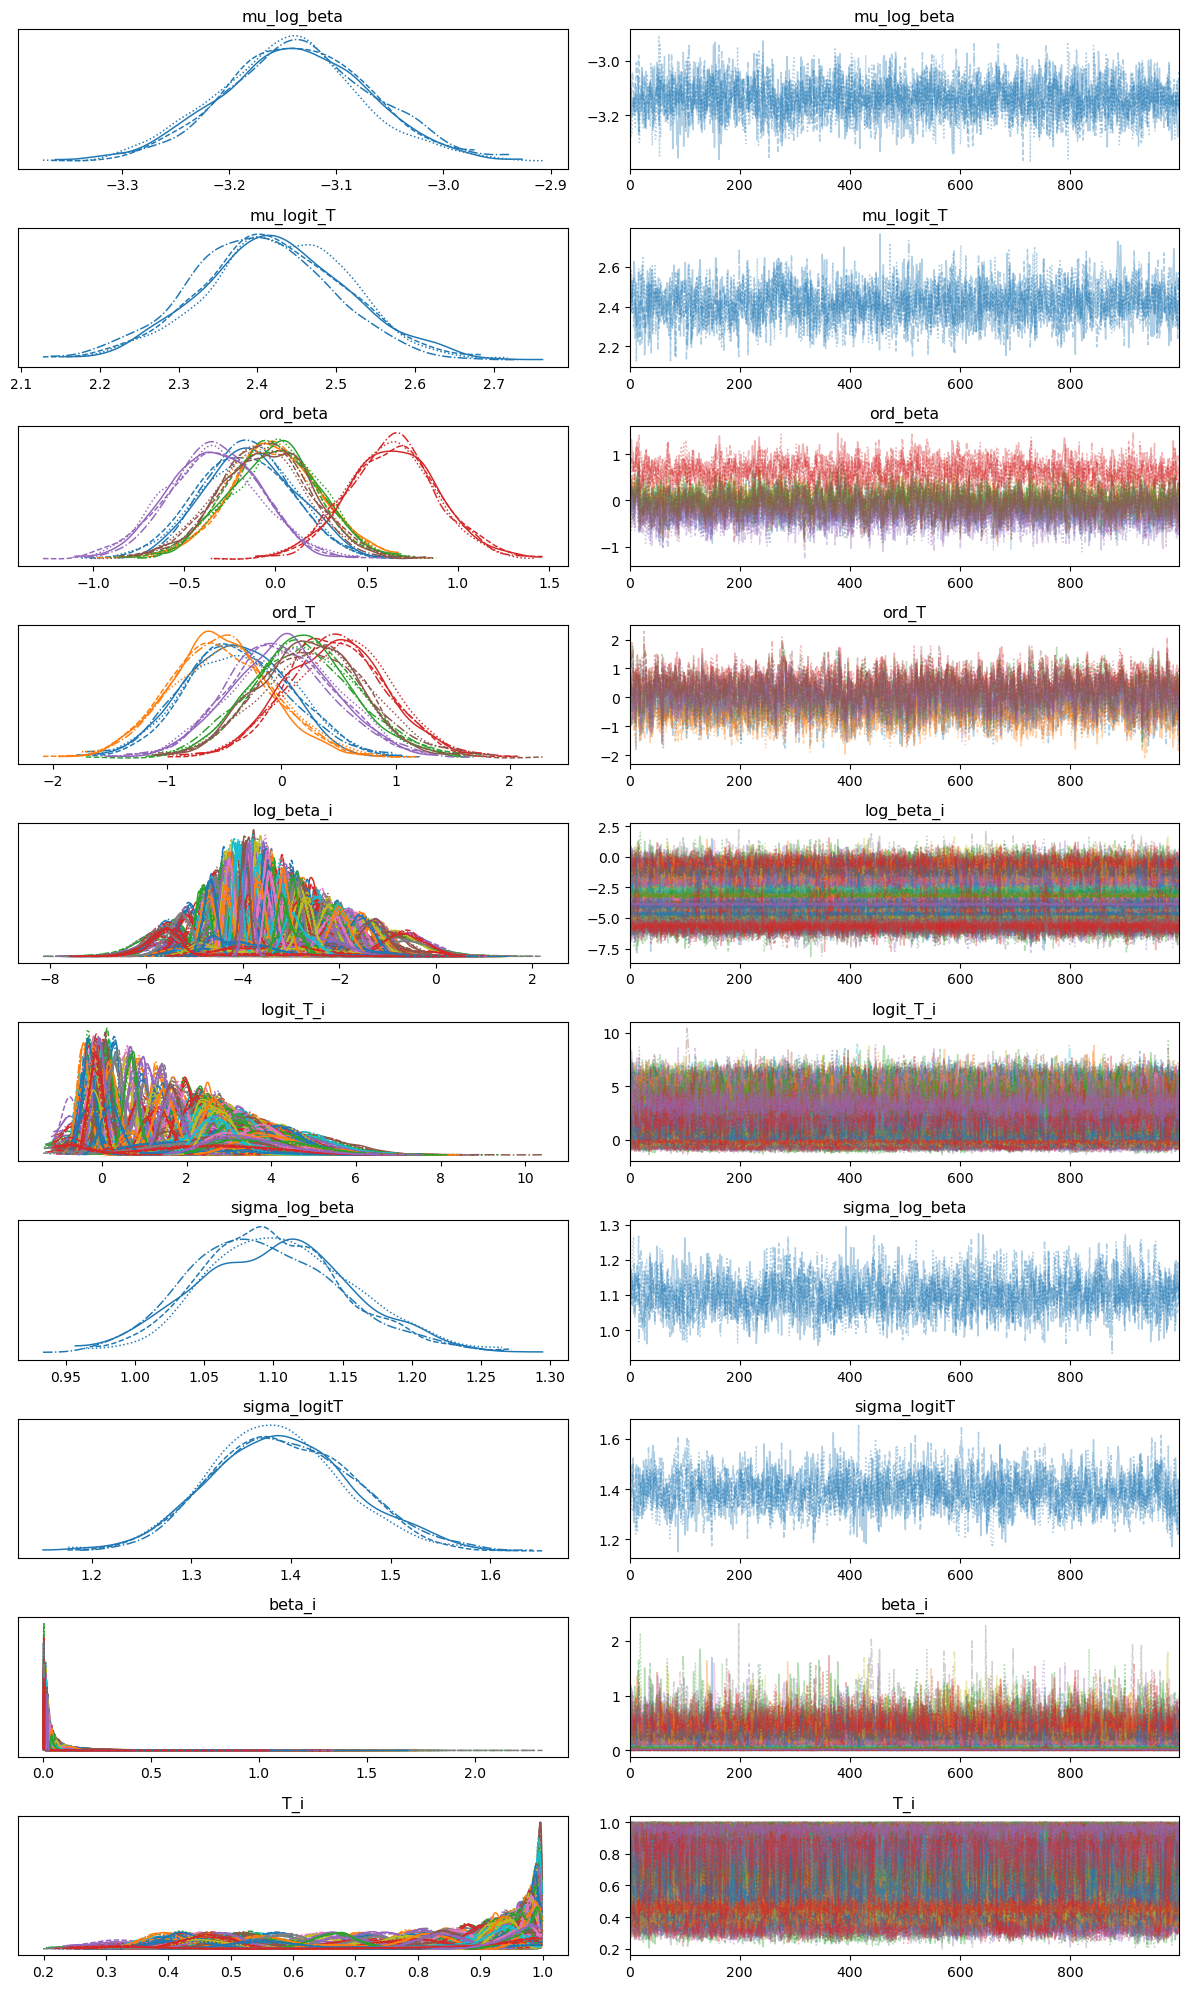

In [45]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

In [48]:
from scipy.special import logit

In [49]:
# numeric participant and order codes
pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
P  = pid_codes.size                       # participants
K  = ord_codes.size                       # order levels

# For the order main effect we need one code *per participant*
order_per_pid = np.zeros(P, dtype=int)
order_per_pid[np.arange(P)] = ord_idx_t[np.searchsorted(pid_idx, np.arange(P))]

# trial indices per row 
t        = df.trial.values.astype("float32")
pid_row  = pid_idx.astype("int32")

beta_row = trace.posterior.beta_i.values[:,::10,pid_row]
T_row = trace.posterior.T_i.values[:,::10,pid_row]

# ---------------- row-wise probabilities --------------------------
# fixed intercept so that p(t=0) = 0.25
logit_intercept = logit(0.25)

# raw logistic (would asymptote to 1 without truncation)
logit_p  = logit_intercept + beta_row * t
p_raw    = 1 / (1 + np.exp(-logit_p))

# truncate at the participant ceiling T
p_row    = np.minimum(p_raw, T_row)

In [50]:
# ---- get p_row draws as (samples, N_rows) -------------------------
# stack chain & draw into one axis for convenience
# shape (N_rows, n_samples)
p_samples = p_row.reshape(-1, p_row.shape[-1])

# ---- basic info from the original dataframe ----------------------
if "partic" not in df.columns or "trial" not in df.columns:
    raise RuntimeError("The dataframe `df` must contain 'partic' and 'trial' columns.")

# re‑index participants 0…P‑1 if not done yet
pid_codes, pid_row = np.unique(df["partic"].values, return_inverse=True)
P = len(pid_codes)

# Convenience: bring trial & correct into arrays aligned with p_row
trial_row   = df["trial"].values
correct_row = df["correct"].values

# -------------------------------------------------------------------
# Create one PNG plot per participant in /mnt/data/
# -------------------------------------------------------------------
for pid in range(P):
    mask = pid_row == pid               # rows for this participant
    if mask.sum() == 0:
        continue

    trials = trial_row[mask]
    order  = np.argsort(trials)
    trials = trials[order]

    # slice & sort posterior samples correspondingly
    p_part = p_samples[:, mask][:, order]   # (samples, n_trials)
    mean   = p_part.mean(axis=0)
    hdi_lo = np.percentile(p_part, 2.5, axis=0)
    hdi_hi = np.percentile(p_part, 97.5, axis=0)

    # ---- plot -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(trials, hdi_lo, hdi_hi, color="tab:blue", alpha=0.25,
                    label="95% HDI")
    ax.plot(trials, mean, color="tab:blue", lw=2, label="posterior mean")

    # overlay raw data (jitter vertically for visibility)
    ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
               s=12, color="black", alpha=0.4, label="observed")

    ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
    ax.set(xlabel="trial", ylabel="accuracy",
           ylim=(-0.05, 1.05),
           title=f"Participant {pid_codes[pid]} – posterior accuracy curve")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()

    # ---- save -----------------------------------------------------
    fname = f"participant_{pid_codes[pid]}_accuracy_logistic.png"
    fig.savefig(fname, dpi=120)
    plt.close(fig)

## Prior preds

In [ ]:
# Set fix_T as needed,
# depending on whether you want a ceiling or not.
# If you set fix_T, you also need to set clip_p to True or the probabilities 
# become too close to 1 for high trials and the model will fail.
fix_T = 1.0 
# fix_T = None
clip_p = True

logistic = define_logistic_model(df, include_p_row=True, fix_T=fix_T, clip_p=clip_p)
n_samples = 10

In [34]:
with logistic:
    prior_pred = pm.sample_prior_predictive(samples=n_samples)


Sampling: [log_beta_i, mu_log_beta, ord_beta, sigma_log_beta, y]


In [ ]:
mu_log_beta = prior_pred.prior['mu_log_beta'].values.flatten()
sigma_log_beta = prior_pred.prior['sigma_log_beta'].values.flatten()

if fix_T is not None:
    mu_logit_T = prior_pred.prior['mu_logit_T'].values.flatten()
    sigma_logit_T = prior_pred.prior['sigma_logitT'].values.flatten()


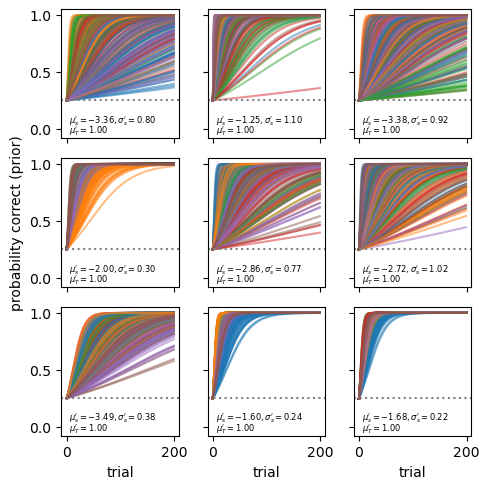

In [40]:
# numeric participant and order codes
pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
P  = pid_codes.size                       # participants
K  = ord_codes.size                       # order levels

fig, axes = plt.subplots(
    3, 
    n_samples//3, 
    figsize=(5, 5), 
    sharex=True, 
    sharey=True
)

for i, ax in enumerate(axes.flatten()):

    content = f"$\\mu_s' = {mu_log_beta[i]:.2f}, \\sigma_s' = {sigma_log_beta[i]:.2f}$\n"
    if fix_T is None:
        content += f"$\\mu_T' = {mu_logit_T[i]:.2f}, \\sigma_T' = {sigma_logit_T[i]:.2f}$"
    else:
        content += f"$\\mu_T' = {fix_T:.2f}$"

    ax.text(
        5, -0.04, 
        content,
        fontsize=6,
        linespacing=0.7
    )

    # shape (# samples, N_rows,)
    p_sim = prior_pred.prior["p_row"].values.squeeze()[i]
    # t_row, pid_row are the same arrays built from df
    t_row   = df.trial.values
    # integer code per row
    pid_row = pid_idx
    P       = pid_codes.size

    # loop over participants
    for pid in range(P):
        
        rows = pid_row == pid
        color = f"C{ord_idx_t[np.argwhere(rows).flatten()[0]]}"
        ax.plot(
            t_row[rows], 
            p_sim[rows], 
            alpha=.5, 
            color=color
        )

    ax.axhline(0.25, color="grey", linestyle=":")

axes[1,0].set_ylabel("probability correct (prior)")
list(map(lambda a: a.set_xlabel('trial'), axes[-1]))
plt.ylim(-0.08, 1.05)
plt.tight_layout()
# fig.savefig('figures/prior_pred.png', dpi=300)
plt.show()

# Model comparison

In [1]:
cascade = define_model(df)
logistic = define_logistic_model(df)
logistic_no_ceiling = define_logistic_model(df, fix_T=True, clip_p=True)

NameError: name 'define_model' is not defined

In [7]:
trace_cascade = az.from_netcdf('../results/cascademodel.cdf')
trace_logistic = az.from_netcdf('../results/logisticmodel.cdf')
trace_logistic_no_ceiling = az.from_netcdf('../results/logisticmodel_no_ceiling.cdf')

In [8]:
thin_every = 5                      # keep every 5‑th draw
idata_thin_cascade = trace_cascade.sel(
    draw=slice(None, None, thin_every),
    # only select first four chains
    chain=slice(0, 3)
)
idata_thin_logistic = trace_logistic.sel(draw=slice(None, None, thin_every))
idata_thin_logistic_no_ceiling = trace_logistic_no_ceiling.sel(draw=slice(None, None, thin_every))

In [9]:
with cascade:
    pm.compute_log_likelihood(
        idata_thin_cascade,
        extend_inferencedata=True
    )

Output()

In [10]:
with logistic:
    pm.compute_log_likelihood(
        idata_thin_logistic,
        extend_inferencedata=True
    )

Output()

In [11]:
with logistic_no_ceiling:
    pm.compute_log_likelihood(
        idata_thin_logistic_no_ceiling,
        extend_inferencedata=True
    )


Output()

In [12]:
print(az.waic(idata_thin_cascade))
print(az.waic(idata_thin_logistic))
print(az.waic(idata_thin_logistic_no_ceiling))


/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 800 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -29387.29   136.29
p_waic      798.01        -

There has been a warning during the calculation. Please check the results.


/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 800 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -29588.16   133.10
p_waic      583.27        -

There has been a warning during the calculation. Please check the results.
Computed from 800 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -31517.66   162.37
p_waic      505.28        -

There has been a warning during the calculation. Please check the results.


/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [19]:
comparison = az.compare(
    {
        "cascade": idata_thin_cascade, 
        "logistic": idata_thin_logistic, 
    }, 
    ic='waic',
)

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [24]:
comparison

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
cascade,0,-29387.290082,798.012500,0.000000,0.832535,136.288369,0.000000,True,log
logistic,1,-29588.163575,583.270223,200.873493,0.167465,133.096425,24.674772,True,log


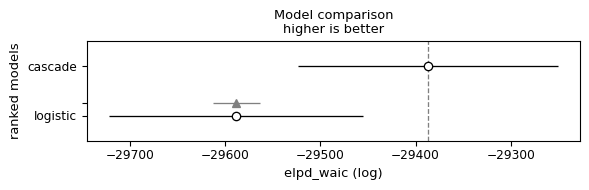

In [27]:
az.plot_compare(comparison, plot_ic_diff=True)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=300)

In [28]:
comparison = az.compare(
    {
        "logistic": idata_thin_logistic, 
        "logistic_no_ceiling": idata_thin_logistic_no_ceiling
    }, 
    ic='waic',
)

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


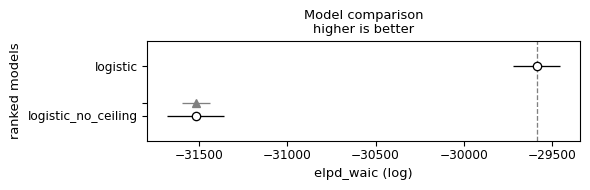

In [29]:
az.plot_compare(comparison, plot_ic_diff=True)
plt.tight_layout()
plt.savefig('figures/model_comparison_no_ceiling.png', dpi=300)

In [17]:
comparison

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
logistic,0,-29588.163575,583.270223,0.000000,0.935041,133.096425,0.000000,True,log
logistic_no_ceiling,1,-31517.658169,505.279320,1929.494594,0.064959,162.370045,78.085004,True,log


In [43]:
waic_bmb = pm.waic(idata_thin)

In [44]:
waic_bmb

Computed from 200 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -31067.17   132.00
p_waic      309.67        -

In [45]:
with cascade:
    pm.compute_log_likelihood(trace)

Output()

In [46]:
waic_cascade = az.waic(trace)

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [47]:
waic_cascade

Computed from 4000 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -29501.53   136.67
p_waic      761.59        -

There has been a warning during the calculation. Please check the results.

In [48]:
df_comp = az.compare({"logistic": waic_bmb, "cascade": waic_cascade}, ic='waic')

In [49]:
df_comp

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
cascade,0,-29501.533528,761.585942,0.000000,0.875596,136.666722,0.000000,True,log
logistic,1,-31067.174764,309.670720,1565.641236,0.124404,132.003678,64.832955,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

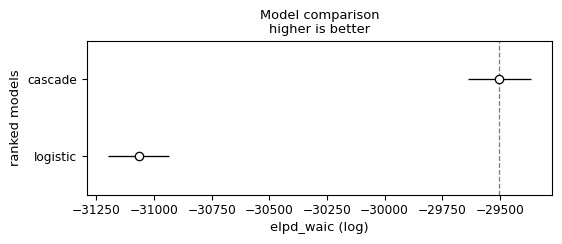

In [50]:
az.plot_compare(df_comp)

# Try to figure out what language participants inferred

In [25]:
# get the point where we are pretty sure the participant finished learning
t_i = trace.posterior.T_i.values
t_i = t_i.reshape(-1, t_i.shape[-1])
# for each row, get the value such that 95% of the values are below that
t_i_95 = np.percentile(t_i, 99, axis=0)


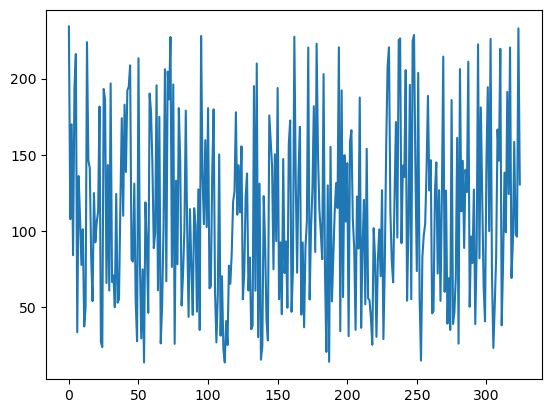

In [26]:
plt.plot(t_i_95)


In [30]:
df['t_i_95'] = df.apply(lambda row: np.clip(t_i_95[row['partic']], 0, 199), axis=1)
df.head()


,trial,partic,order,correct,t_i_95
0,0,0,osv,1,199.000000
1,0,1,ovs,0,107.887707
2,0,2,svo,0,170.095384
3,0,3,vso,0,84.241612
4,0,4,sov,0,194.225397


<Axes: xlabel='t_i_95', ylabel='Count'>

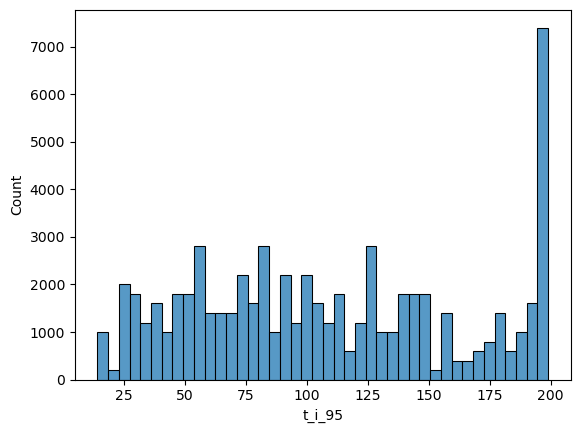

In [36]:
sns.histplot(df['t_i_95'])


In [ ]:
from scripts.simulation_functions import define_objects

<function scripts.simulation_functions.define_objects(n_beings=4, n_actions=3, full_output=False)>